# PVSim Fault Injection Showcase

Runs two simulations (healthy baseline and faulty) using the story defined in `data/settings.json`, then plots the results.

In [1]:
import json
import warnings
from src import WeatherModel, Simulation
from src import plot

warnings.filterwarnings("ignore", category=RuntimeWarning)

with open("data/settings.json") as f:
    story = json.load(f)

with open("data/modules.json") as f:
    systems = json.load(f)

## Healthy baseline

Same systems and timeframe, but no faults injected.

In [2]:
healthy_story = {"timeframe": story["timeframe"], "faults": {}}
wm = WeatherModel.WeatherModel()

sim_healthy = Simulation.Simulation(systems, wm, healthy_story)
sim_healthy.run(save=False)

[C] fault_list: []
[C] fault_list: []


## Faulty simulation

Same systems and timeframe, faults loaded from `data/settings.json`.

In [3]:
sim_faulty = Simulation.Simulation(systems, wm, story)
sim_faulty.run(save=False)

[C] fault_list: ['degradation', 'pid', 'open_string']
[C] fault_list: ['soiling', 'inverter_fault']
[C] inverter_fault applied to window 2023-02-10 00:00:00+01:00 - 2023-03-05 00:00:00+01:00 (553 timesteps)


## Results

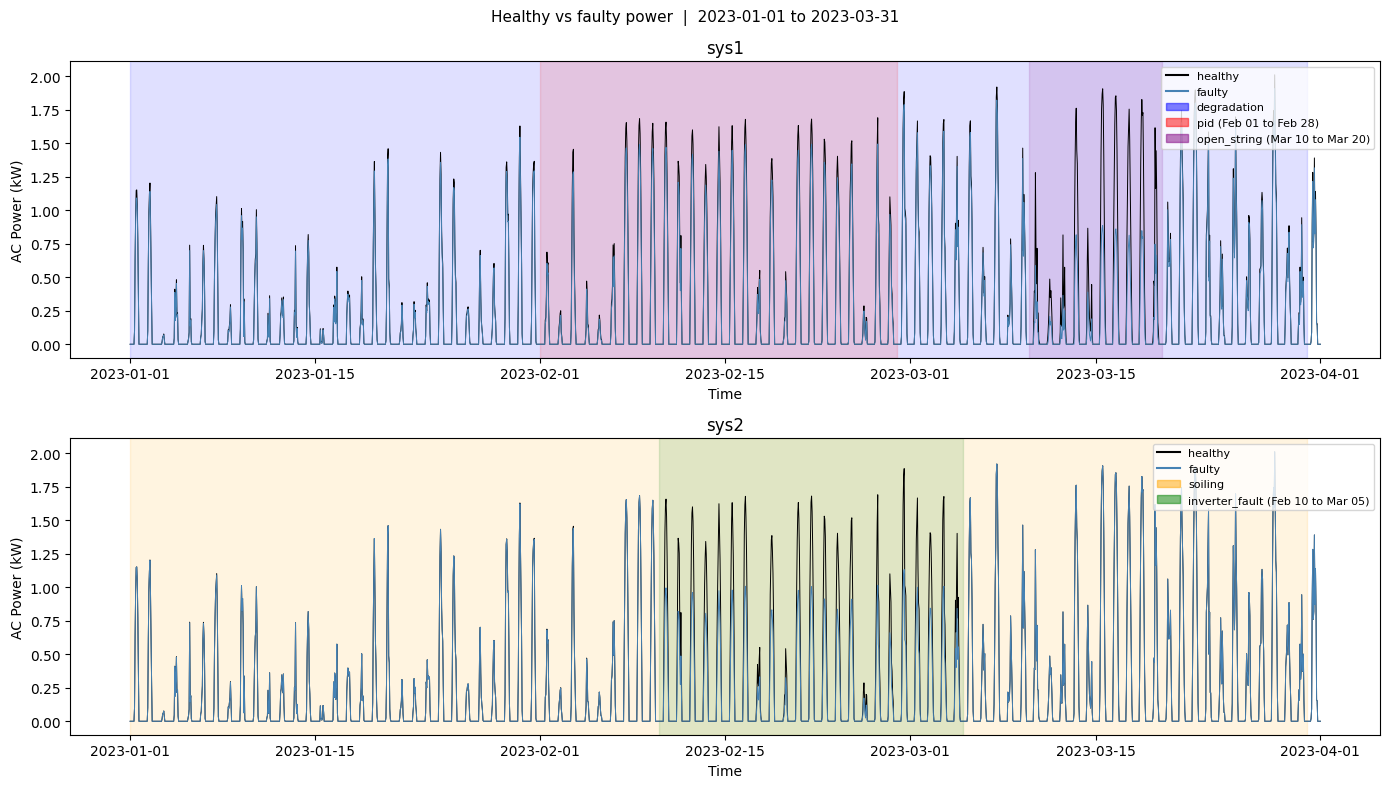

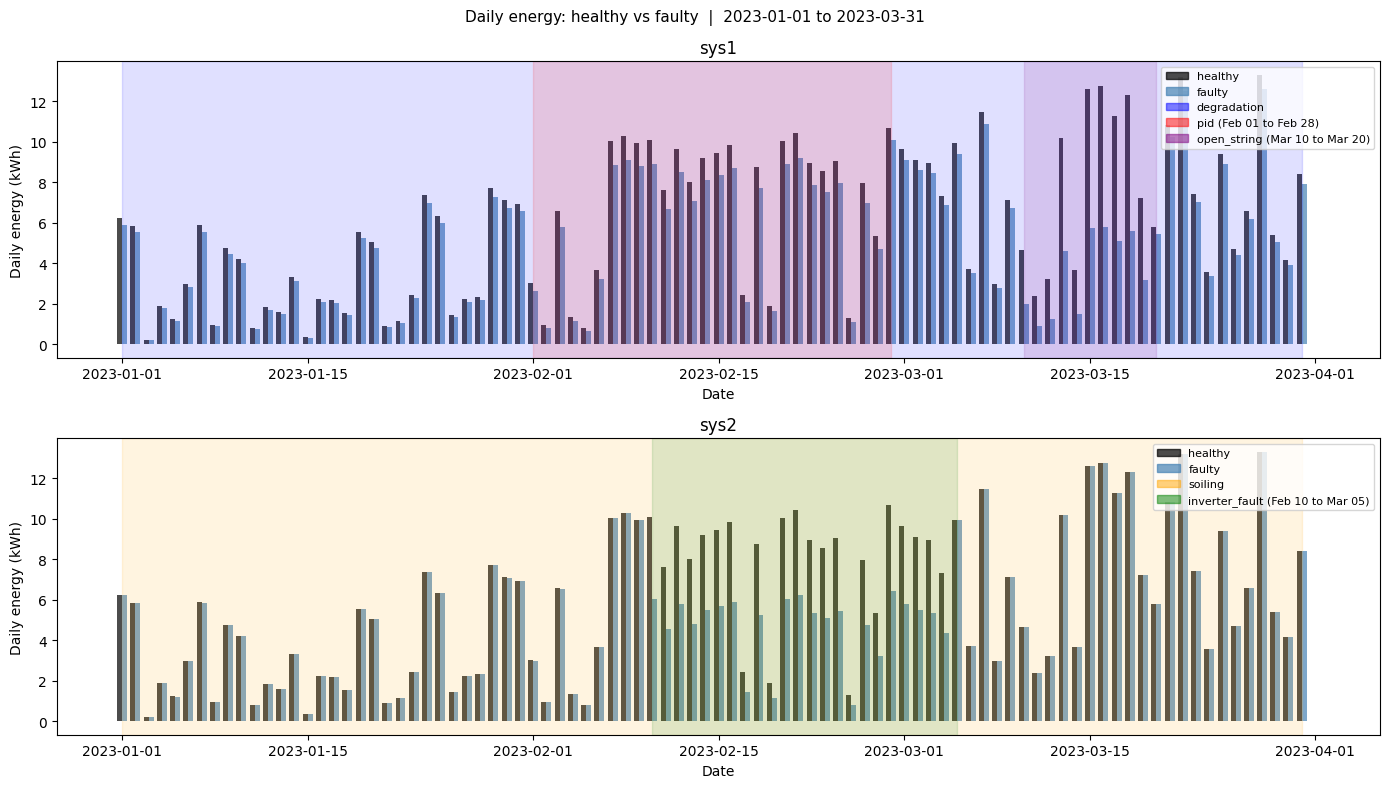

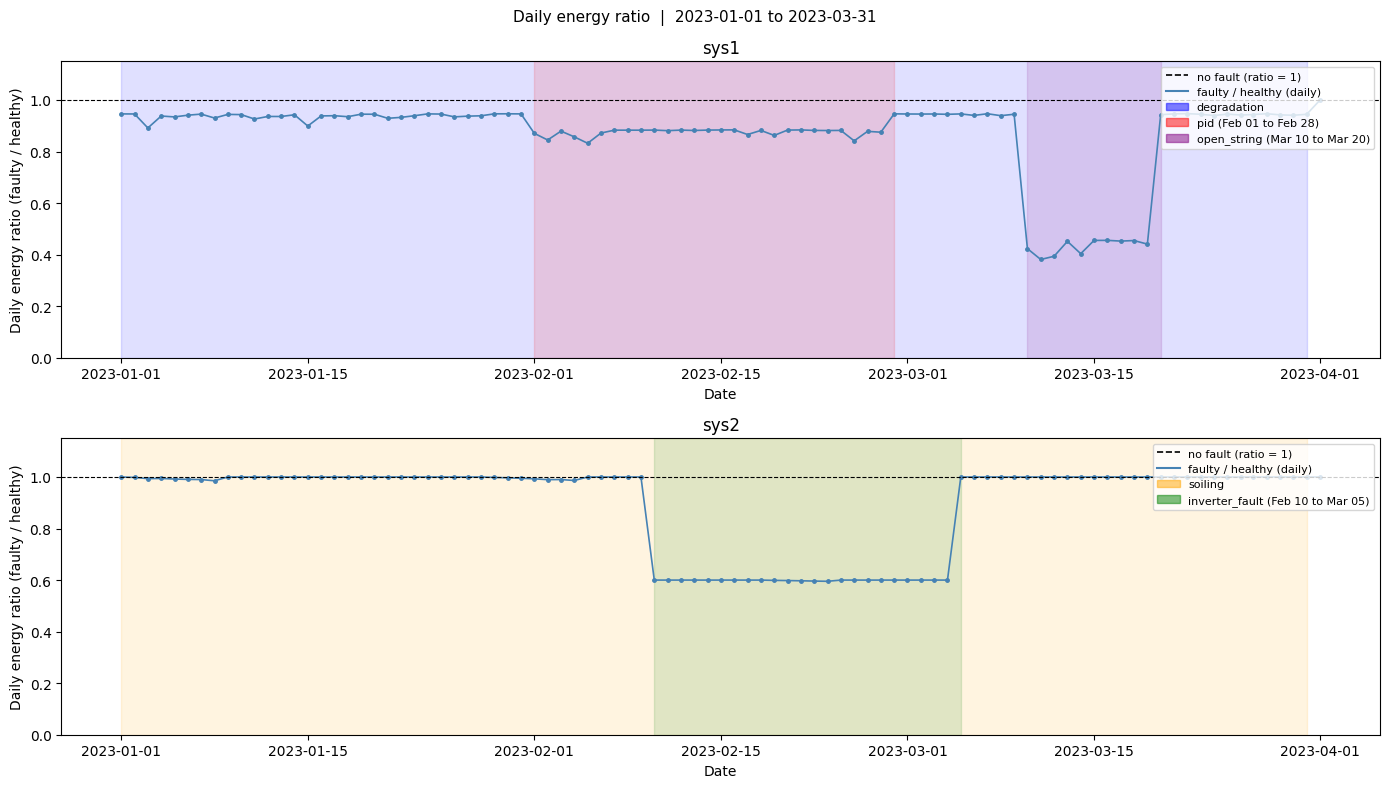

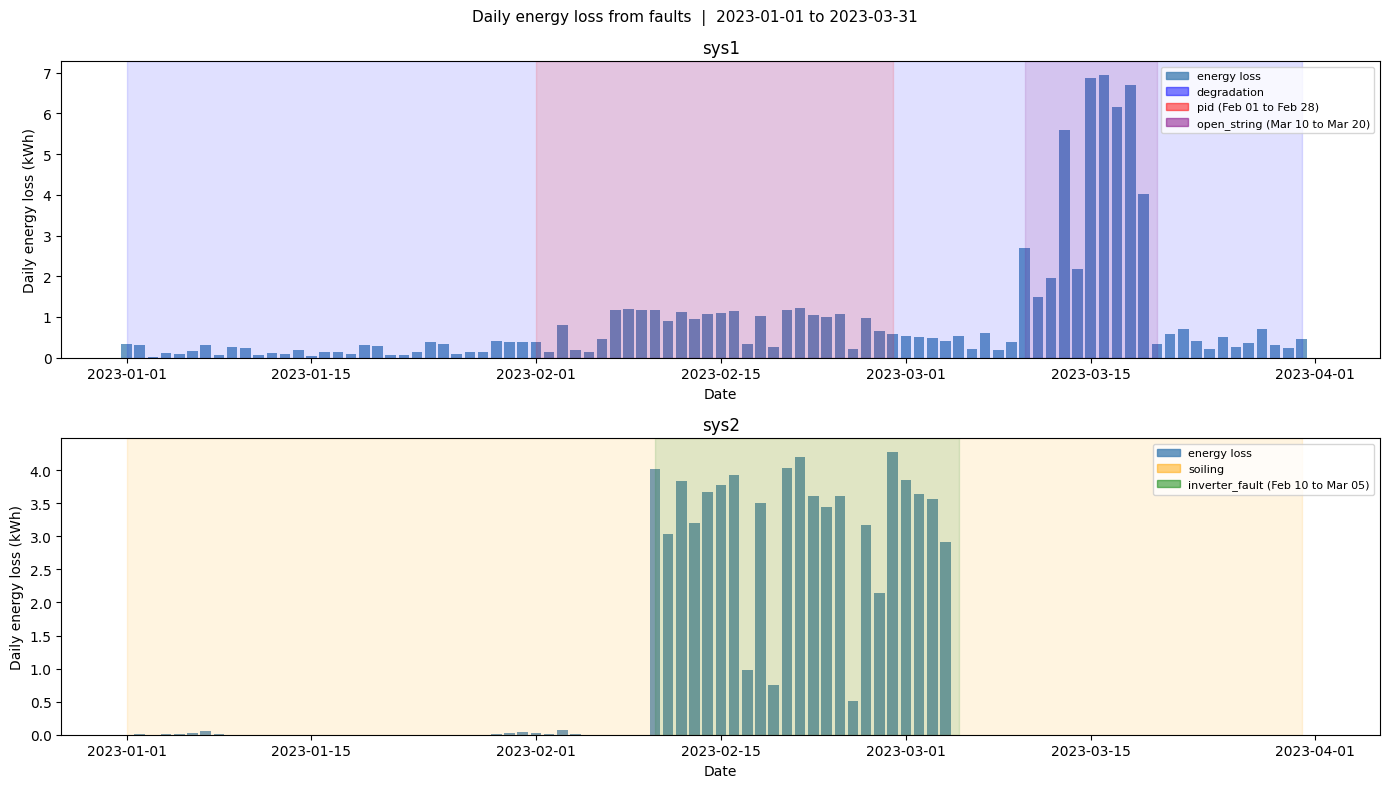

In [4]:
plot.plot_power_comparison(sim_healthy, sim_faulty, story, systems)
plot.plot_daily_energy_comparison(sim_healthy, sim_faulty, story, systems)
plot.plot_power_ratio(sim_healthy, sim_faulty, story, systems)
plot.plot_daily_energy_loss(sim_healthy, sim_faulty, story, systems)